In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [71]:
df=pd.read_csv('height-weight.csv')

In [72]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [73]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


Text(0, 0.5, 'Weight')

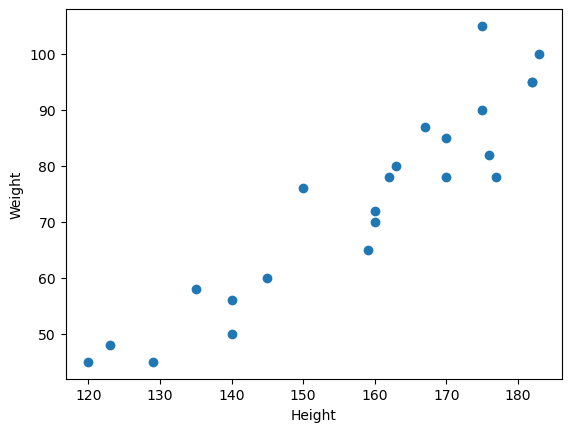

In [74]:
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')

Text(0, 0.5, 'Height')

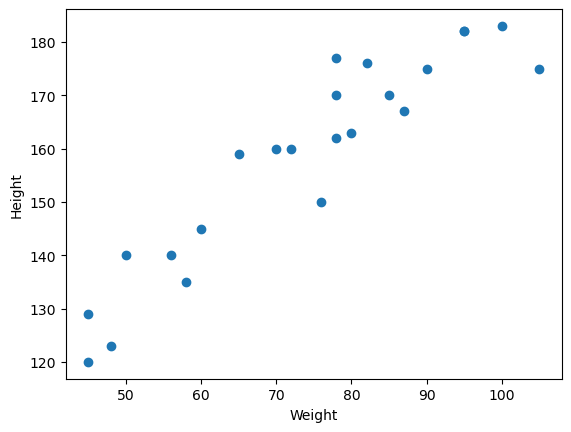

In [75]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [76]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


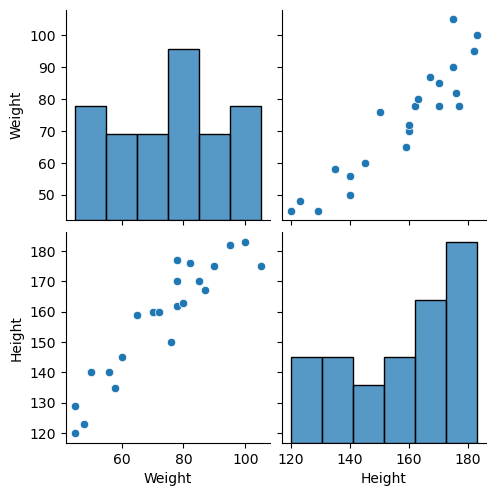

In [77]:
import seaborn as sns
sns.pairplot(df)


<Axes: >

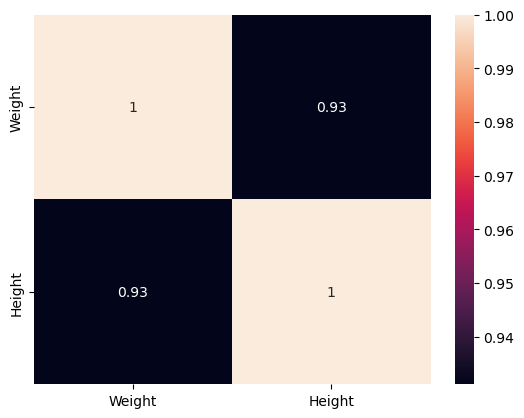

In [78]:
sns.heatmap(df.corr(),annot=True)

In [79]:
X=df['Weight']
X

0      45
1      58
2      48
3      60
4      70
5      78
6      80
7      90
8      95
9      78
10     82
11     95
12    105
13    100
14     85
15     78
16     50
17     65
18     76
19     87
20     45
21     56
22     72
Name: Weight, dtype: int64

In [80]:
Y=df['Height']
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [81]:
type(X)
type(Y)

pandas.core.series.Series

In [82]:
np.array(X)

array([ 45,  58,  48,  60,  70,  78,  80,  90,  95,  78,  82,  95, 105,
       100,  85,  78,  50,  65,  76,  87,  45,  56,  72])

In [83]:
np.array(X).reshape(-1,1)

array([[ 45],
       [ 58],
       [ 48],
       [ 60],
       [ 70],
       [ 78],
       [ 80],
       [ 90],
       [ 95],
       [ 78],
       [ 82],
       [ 95],
       [105],
       [100],
       [ 85],
       [ 78],
       [ 50],
       [ 65],
       [ 76],
       [ 87],
       [ 45],
       [ 56],
       [ 72]])

In [84]:
np.array(Y).reshape(-1,1)

array([[120],
       [135],
       [123],
       [145],
       [160],
       [162],
       [163],
       [175],
       [182],
       [170],
       [176],
       [182],
       [175],
       [183],
       [170],
       [177],
       [140],
       [159],
       [150],
       [167],
       [129],
       [140],
       [160]])

In [85]:
from sklearn.model_selection import train_test_split   
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [86]:
X_train = np.array(X_train).reshape(-1, 1)

In [87]:
X_train.shape

(17, 1)

In [88]:
print(X_train.dtype)

int64


In [89]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [90]:
X_train=scaler.transform(X_train)

In [91]:
X_test

15     78
9      78
0      45
8      95
17     65
12    105
Name: Weight, dtype: int64

In [92]:
from sklearn.linear_model import LinearRegression

In [93]:
regression=LinearRegression(n_jobs=-1)

In [95]:
regression.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [96]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [285.5432526]
Intercept: 1410.0817310456048


Plot Training data

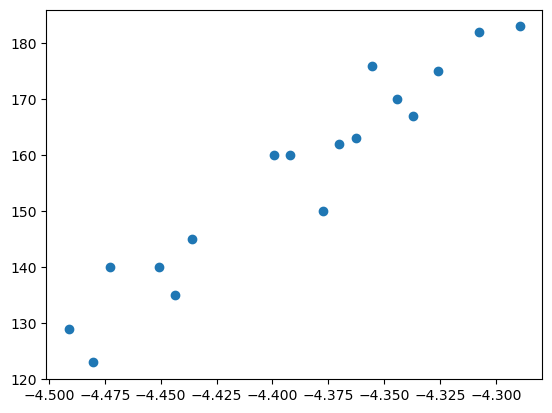

In [97]:
plt.scatter(X_train,Y_train)

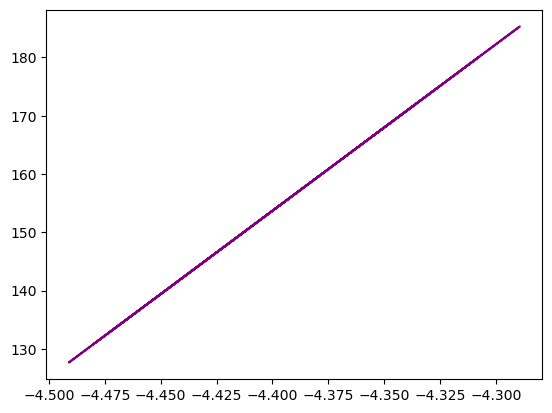

In [99]:
plt.plot(X_train,regression.predict(X_train),color='purple')

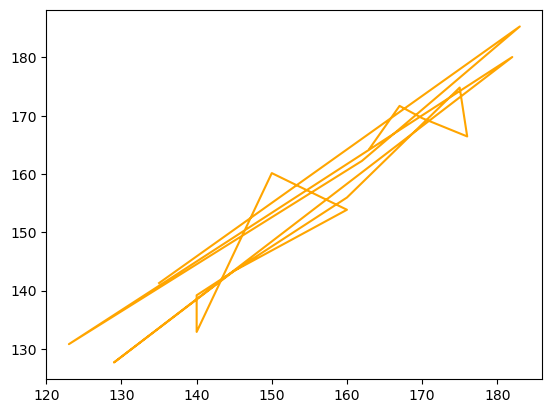

In [102]:
plt.plot(Y_train,regression.predict(X_train),color='orange')

In [104]:

X_test = np.array(X_test).reshape(-1, 1)
y_pred = regression.predict(X_test)

In [109]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error


In [115]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=root_mean_squared_error(Y_test,y_pred)
sm=mean_squared_error(Y_test,y_pred)
rsme=np.sqrt(sm)
print(mse)
print(mae)
print(rmse)

579376136.5819222
23423.441015936027
24070.233413532205


In [116]:
score=r2_score(Y_test,y_pred)
print(score)

-1331473.045129218


In [121]:
import statsmodels.api as sm
model=sm.OLS(Y_train,X_train).fit()

In [122]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.984
Model:                            OLS   Adj. R-squared (uncentered):              0.983
Method:                 Least Squares   F-statistic:                              965.9
Date:                Mon, 06 Jul 2026   Prob (F-statistic):                    9.83e-16
Time:                        14:56:17   Log-Likelihood:                         -75.139
No. Observations:                  17   AIC:                                      152.3
Df Residuals:                      16   BIC:                                      153.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [126]:
##prediction for new data
regression.predict(scaler.transform([[72]]))

array([1401.94139895])